## Part 3 Explain the concept of TF-IDF in your own words and how it can help you understand the genres and communities.

**TF (term frequency):** How common a genre is inside that community — for example, *grunge* shows up a lot in a grunge cluster.

**IDF (inverse document frequency):** How rare that genre is across all communities. Genres that pop up everywhere (like "rock") get down‑weighted, this means that niche genres that concentrate in one community get up‑weighted.

**TF x IDF:** Highlights genres that are both common within one community and uncommon elsewhere — it's the algorithmic nose that tells you *this cluster smells like glam metal, not just generic rock*.


In [22]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import networkx as nx
import community.community_louvain as louvain 
from IPython.display import display

In [24]:
def load_graph_with_genres(path_candidates):
    for p in path_candidates:
        if os.path.exists(p):
            try:
                G = nx.read_graphml(p)
                genres_attr = nx.get_node_attributes(G, "genres")

                if genres_attr:
                    for n, s in genres_attr.items():
                        if isinstance(s, str):
                            genres = [g.strip().lower() for g in s.split(";") if g.strip()]
                            G.nodes[n]["_genres_list"] = genres
                else:
                    base = os.path.splitext(p)[0]
                    json_path = base + "_genres.json"
                    if os.path.exists(json_path):
                        with open(json_path, "r", encoding="utf-8") as f:
                            mapping = json.load(f)
                        for n in G.nodes:
                            genres = mapping.get(n, [])
                            G.nodes[n]["_genres_list"] = [g.strip().lower() for g in genres]
                return G, os.path.basename(p)
            except:
                pass
    return None, None


def compute_communities(G):
    H = G.to_undirected()

    part = louvain.best_partition(H, random_state=15)
    for n, c in part.items():
        G.nodes[n]["community"] = c

    groups = {}
    for n, c in part.items():
        groups.setdefault(c, []).append(n)
    comms = [nodes for _, nodes in sorted(groups.items(), key=lambda x: -len(x[1]))]
    return comms, "louvain"


def build_genre_documents(G, communities):
    docs = []
    for nodes in communities:
        bag = []
        for n in nodes:
            genres = G.nodes[n].get("_genres_list") or []
            bag.extend(genres)
        docs.append(bag)
    return docs


def compute_tfidf(docs):
    N = len(docs)
    vocab = sorted(set(term for doc in docs for term in doc))
    index = {t: i for i, t in enumerate(vocab)}

    tf = np.zeros((N, len(vocab)), dtype=float)
    for d, doc in enumerate(docs):
        counts = Counter(doc)
        total = sum(counts.values())
        for term, c in counts.items():
            tf[d, index[term]] = c / total if total > 0 else 0

    df = np.array([sum(1 for doc in docs if t in doc) for t in vocab])
    idf = np.log((1 + N) / (1 + df)) + 1.0
    tfidf = tf * idf

    return vocab, tfidf, tf, idf, df


def show_heatmap(df_tfidf, top_k=20):
    sums = df_tfidf.sum(axis=0).sort_values(ascending=False)
    keep = sums.head(top_k).index.tolist()
    sub = df_tfidf[keep]

    plt.figure(figsize=(12, 6))
    plt.imshow(sub.values, aspect="auto", cmap="viridis")
    plt.colorbar(label="TF-IDF")
    plt.yticks(range(len(sub.index)), sub.index)
    plt.xticks(range(len(keep)), keep, rotation=45, ha="right")
    plt.title("Top Genres per Community (TF-IDF)")
    plt.show()


def show_top_bars(df_tfidf, top_n=10):
    for comm in df_tfidf.index:
        top = df_tfidf.loc[comm].sort_values(ascending=False).head(top_n)
        plt.figure(figsize=(10, 4))
        plt.bar(top.index, top.values)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Top {top_n} Genres — Community {comm}")
        plt.show()


In [25]:
graph_candidates = ["rock_network_with_genres.graphml"]
G, base_name = load_graph_with_genres(graph_candidates)

if G is None:
    raise FileNotFoundError("⚠️ rock_network_with_genres.graphml not found. Put it next to the notebook.")


In [26]:
communities, method = compute_communities(G)
docs = build_genre_documents(G, communities)
vocab, tfidf, tf, idf, df = compute_tfidf(docs)

comm_labels = list(range(len(communities)))
df_tfidf = pd.DataFrame(tfidf, index=comm_labels, columns=vocab)

Found 6 communities using louvain.

🎸 Community 0 (150 artists):
Frank Zappa, Mitch Ryder, Bo Diddley, Little Richard, Paul McCartney ...

🎸 Community 1 (147 artists):
Ramones, Pearl Jam, U2, Radiohead, Run-DMC ...

🎸 Community 2 (89 artists):
Ted Nugent, Damn Yankees (band), Skid Row (American band), Pantera, Anthrax (American band) ...

🎸 Community 3 (55 artists):
Stone Temple Pilots, Nickelback, Godsmack, Limp Bizkit, Staind ...

🎸 Community 4 (40 artists):
Styx (band), Foreigner (band), Meat Loaf, Kid Rock, Heart (band) ...

🎸 Community 5 (3 artists):
Parliament (band), Funkadelic, Parliament-Funkadelic



,acid rock,acoustic rock,allmusic,alternative metal,alternative metal art rock shoegaze,alternative metal funk metal alternative rock experimental rock,alternative metal funk metal experimental rock progressive rock,alternative metal gothic metal gothic rock hard rock industrial rock symphonic metal nu metal,alternative metal hard rock,alternative metal hard rock nu metal,...,synth pop,texas blues,the daily aztec,the new york times,thrash metal,thrash metal groove metal,western swing,western/cowboy,worldbeat,yacht rock
0,0.003536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00596,0.000000,0.0,0.000000,0.000000,0.00596,0.00596,0.000000,0.000000
1,0.004739,0.007989,0.000000,0.011061,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.031954,0.00000,0.007989,0.0,0.000000,0.000000,0.00000,0.00000,0.007989,0.000000
2,0.000000,0.000000,0.000000,0.026434,0.000000,0.019091,0.019091,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.0,0.038182,0.019091,0.00000,0.00000,0.000000,0.000000
3,0.000000,0.000000,0.027166,0.022936,0.033129,0.000000,0.000000,0.033129,0.033129,0.033129,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
4,0.010866,0.000000,0.030037,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,0.018315


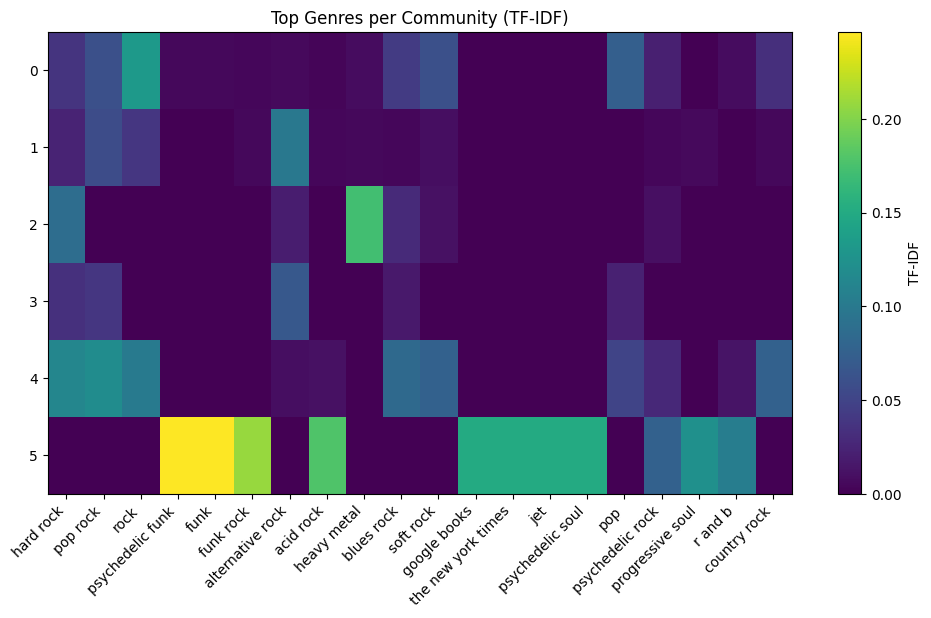

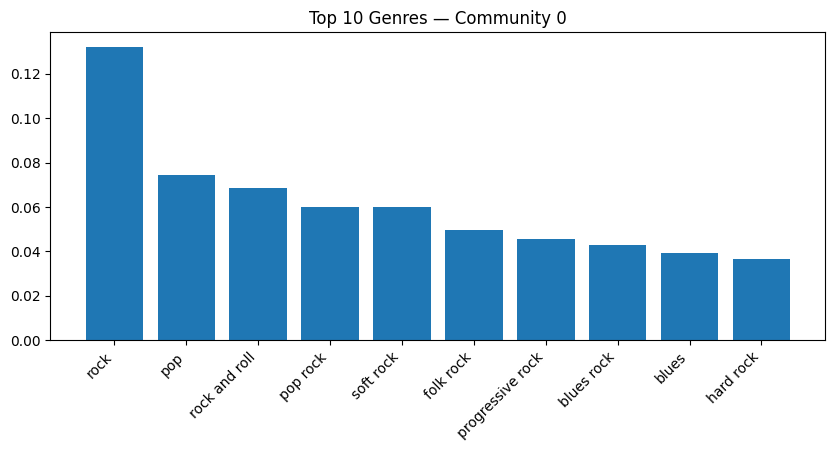

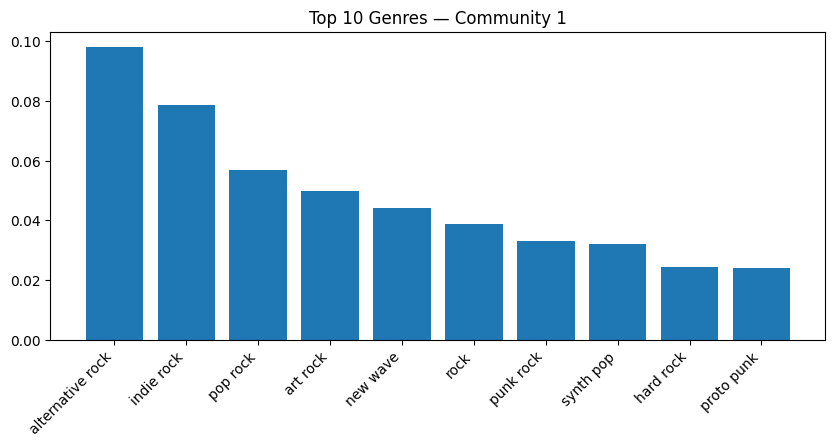

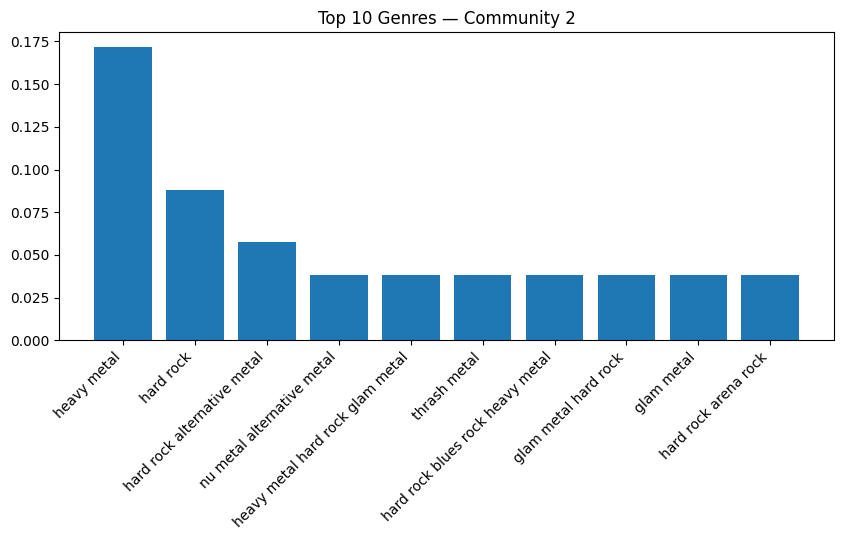

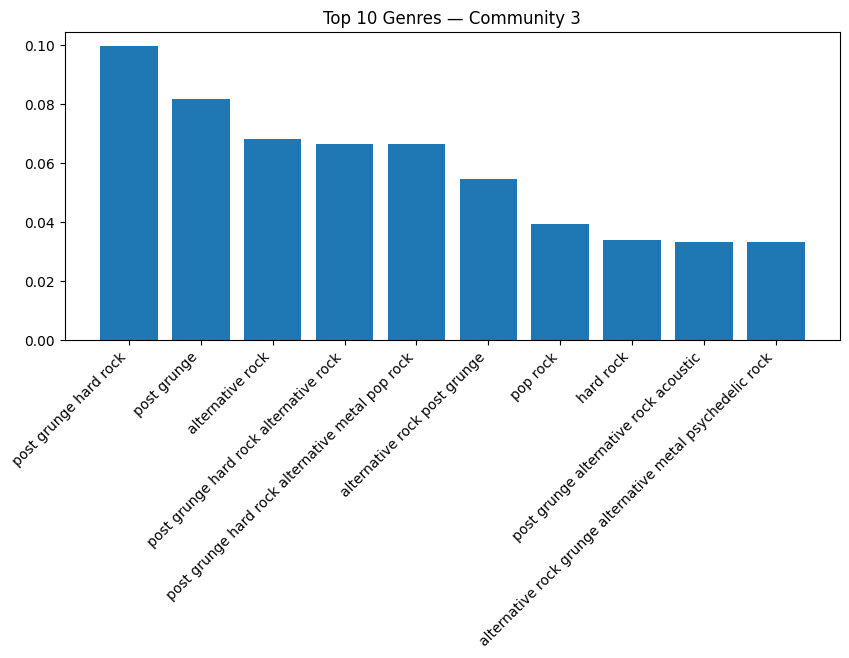

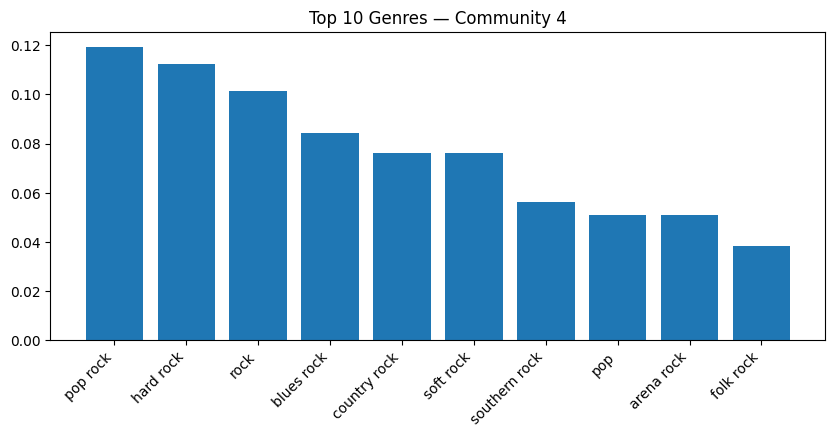

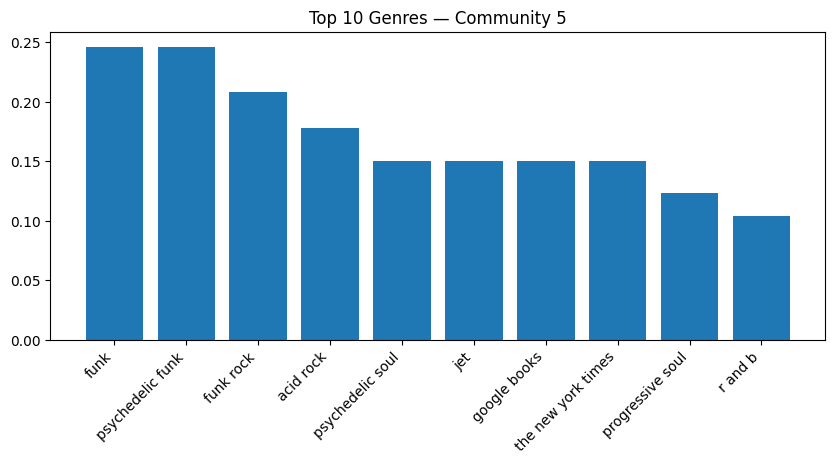

In [27]:
print(f"Found {len(communities)} communities using {method}.\n")

for i, nodes in enumerate(communities):
    print(f"🎸 Community {i} ({len(nodes)} artists):")
    print(", ".join(nodes[:5]) + (" ..." if len(nodes) > 5 else ""))
    print()

display(df_tfidf.head())

show_heatmap(df_tfidf, top_k=20)
show_top_bars(df_tfidf, top_n=10)

# Calculate and visualize TF-IDF for the genres and communities.

Using Louvain on the artist network, we found 5 communities (sizes: 150, 147, 89, 55, 3). Running TF-IDF on node genres highlights what’s distinctive for each group rather than what’s merely popular.

The network’s structure matches genre history: classic/roots, indie/alt, heavy/metal, post-grunge/alt-metal. TF-IDF surfaces what makes each cluster unique, letting us interpret communities as stylistic neighborhoods rather than generic “popularity.”

In [28]:
for node in G.nodes():
    for key, value in G.nodes[node].items():
        if isinstance(value, list):
            G.nodes[node][key] = ";".join(value)

# Save the graph for future use
nx.write_graphml(G, "rock_network_with_communities.graphml")


# Load enriched graph
#G = nx.read_graphml("rock_network_with_communities_and_sentiment.graphml")

node_genres = {
    n: [g.strip() for g in str(G.nodes[n].get("genres", "")).split(";") if g.strip()]
    for n in G.nodes()
}

# Community assignment
# Assume each node has a "community" attribute created earlier
node_comms = {n: G.nodes[n].get("community") for n in G.nodes()}

# Count genres overall
genre_counts = Counter([g for genres in node_genres.values() for g in genres])
top_genres = [g for g, _ in genre_counts.most_common(7)]

# Count communities by size
comm_counts = Counter([c for c in node_comms.values() if c is not None])
print("Community sizes:", comm_counts.most_common(7))
top_comms = [c for c, _ in comm_counts.most_common(7)]

print("Top genres:", top_genres)
print("Top communities:", top_comms)

# Build confusion matrix
matrix = pd.DataFrame(
    0, index=top_genres, columns=top_comms, dtype=int
)

for node in G.nodes():
    comm = node_comms[node]
    genres = node_genres[node]

    if comm not in top_comms:
        continue

    # consider all genres for that node
    for g in genres:
        if g in top_genres:
            matrix.loc[g, comm] += 1

print("\nConfusion matrix (genre x community):\n")
print(matrix)

# Normalize by row (optional, to interpret purity of genres by community)
row_norm = matrix.div(matrix.sum(axis=1), axis=0)
print("\nRow-normalized version:\n")
print(row_norm.round(2))


Community sizes: [(3, 150), (1, 147), (0, 89), (2, 55), (4, 40), (5, 3)]
Top genres: ['rock', 'pop rock', 'hard rock', 'alternative rock', 'blues rock', 'soft rock', 'pop']
Top communities: [3, 1, 0, 2, 4, 5]

Confusion matrix (genre x community):

                   3   1  0  2   4  5
rock              32   7  0  0   8  0
pop rock          17  12  0  2  11  0
hard rock         12   6  9  2  12  0
alternative rock   2  24  2  4   1  0
blues rock        14   1  3  1   9  0
soft rock         17   2  1  0   7  0
pop               18   0  0  1   4  0

Row-normalized version:

                     3     1     0     2     4    5
rock              0.68  0.15  0.00  0.00  0.17  0.0
pop rock          0.40  0.29  0.00  0.05  0.26  0.0
hard rock         0.29  0.15  0.22  0.05  0.29  0.0
alternative rock  0.06  0.73  0.06  0.12  0.03  0.0
blues rock        0.50  0.04  0.11  0.04  0.32  0.0
soft rock         0.63  0.07  0.04  0.00  0.26  0.0
pop               0.78  0.00  0.00  0.04  0.17  0.0


## Use the matrix d (Lecture 7, part 2) to dicusss the difference between the word-clouds between genres and communities.

Genres group by labels; communities group by network structure, so their word‑clouds need not match. The matrix shows where to expect overlap. Alternative rock is concentrated in community 1 (0.73), so its genre cloud should closely resemble community 1. Hard rock is split across communities 3 (0.29), 4 (0.29), and 0 (0.22), and pop rock across 3 (0.40), 1 (0.29), and 4 (0.26), so their genre clouds will blend multiple community vocabularies. Community 3 is the largest (150 nodes) and dominates rock (0.68), soft rock (0.63), and pop (0.78), so these genre clouds will reflect broad, high‑frequency terms typical of community 3. Blues rock shows a mixed profile with community 3 (0.50) and 4 (0.32). So to summarize: concentrated genres align with their main community; dispersed genres produce hybrid word‑clouds. This explains why community clouds can look sharper or broader than genre clouds even when they share many artists.

## Part 4 Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.

In [30]:
import re
import math
import requests
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import mwparserfromhell

%matplotlib inline

GRAPH_PATH = "rock_network_with_communities.graphml"
OUTPUT_GRAPH = "rock_network_with_communities_and_sentiment.graphml"

# Wikipedia API settings
WIKI_API = "https://en.wikipedia.org/w/api.php"
USER_AGENT = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/142.0.0.0 Safari/537.36"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})


In [31]:
def download_labmt() -> dict:
    """Download the LabMT word list (TSV) and return dict: word -> happiness score (float)."""
    # Direct link to PLOS ONE supplementary data for 'Temporal Patterns of Happiness and Information...'
    url = "https://journals.plos.org/plosone/article/file?type=supplementary&id=info:doi/10.1371/journal.pone.0026752.s001"
    r = SESSION.get(url, timeout=60)
    r.raise_for_status()
    text = r.text
    labmt = {}
    # File has a header line; columns include 'word' and 'happiness_average' (or similar)
    lines = text.splitlines()
    if lines:

        word_idx=0
        happ_idx = 2
        for line in lines[3:]:
            parts = line.rstrip("\n").split("\t")
            if len(parts) <= max(word_idx, happ_idx):
                continue
            w = parts[word_idx].strip().lower()
            try:
                s = float(parts[happ_idx])
            except ValueError:
                continue
            if w:
                labmt[w] = s
    return labmt

labmt = download_labmt()
len(labmt), list(list(labmt.items())[:5])


(10222,
 [('laughter', 8.5),
  ('happiness', 8.44),
  ('love', 8.42),
  ('happy', 8.3),
  ('laughed', 8.26)])

In [32]:

def sentiment_score(tokens, labmt, drop_neutral=False, neutral_low=4.0, neutral_high=6.0):
    """
    Compute LabMT-style sentiment score for a list of lowercase tokens.
    If drop_neutral=True, words with happiness in [neutral_low, neutral_high] are ignored.
    Returns np.nan if no scored tokens remain.
    """
    scores = []
    for t in tokens:
        s = labmt.get(t)
        if s is None:
            continue
        if drop_neutral and (neutral_low <= s <= neutral_high):
            continue
        scores.append(s)
    if not scores:
        return np.nan
    return float(np.mean(scores))


In [33]:

def fetch_wikitext(title: str) -> str:
    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "rvprop": "content",
        "rvslots": "main",
        "titles": title,
    }
    r = SESSION.get(WIKI_API, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    pages = data.get("query", {}).get("pages", {})
    for _, page in pages.items():
        revs = page.get("revisions")
        if not revs:
            return ""
        return revs[0].get("slots", {}).get("main", {}).get("*", "")
    return ""


In [35]:

# Load the graph (only local file dependency)
G = nx.read_graphml(GRAPH_PATH)
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Work on sub-network of artists that have a 'genres' attribute
nodes_with_genre = [n for n in G.nodes if G.nodes[n].get("genres")]
print(f"Artists with genres: {len(nodes_with_genre)}")

def get_page_text_for_node(n):
    # Prefer any stored text attributes if present
    for key in ["wikitext", "page_text", "text", "content"]:
        v = G.nodes[n].get(key)
        if v and isinstance(v, str) and len(v) > 50:
            return v
    # Otherwise fetch from Wikipedia
    title = str(n)
    wt = fetch_wikitext(title)
    return wt or ""

sentiment_map = {}
missing_text = 0

for i, n in enumerate(nodes_with_genre, 1):
    raw = get_page_text_for_node(n)
    if not raw:
        missing_text += 1
        sentiment_map[n] = np.nan
        continue
    # Strip wikitext to plain text
    plain = mwparserfromhell.parse(raw).strip_code()
    tokens = re.findall(r"[a-zA-Z']+", plain.lower())
    score = sentiment_score(tokens, labmt, drop_neutral=False)
    sentiment_map[n] = score
    G.nodes[n]["sentiment"] = score

print(f"Pages with missing/empty text: {missing_text}")


Nodes: 484, Edges: 7267
Artists with genres: 481
Pages with missing/empty text: 0


In [36]:
#Save the graph with sentiment attribute
nx.write_graphml(G, OUTPUT_GRAPH)
# Gather finite sentiment values
vals = np.array([v for v in sentiment_map.values() if isinstance(v, (int, float)) and not np.isnan(v)])

print(f"Valid sentiment pages: {len(vals)}")
if len(vals) == 0:
    raise RuntimeError("No valid sentiment values computed. Ensure pages have retrievable text.")

mean_s = float(np.mean(vals))
median_s = float(np.median(vals))
var_s = float(np.var(vals, ddof=1)) if len(vals) > 1 else float("nan")
q25 = float(np.percentile(vals, 25))
q75 = float(np.percentile(vals, 75))

summary = {
    "mean": round(mean_s, 3),
    "median": round(median_s, 3),
    "variance": round(var_s, 3) if not math.isnan(var_s) else None,
    "q25": round(q25, 3),
    "q75": round(q75, 3),
}
summary


Valid sentiment pages: 481


{'mean': 5.532, 'median': 5.531, 'variance': 0.003, 'q25': 5.496, 'q75': 5.569}

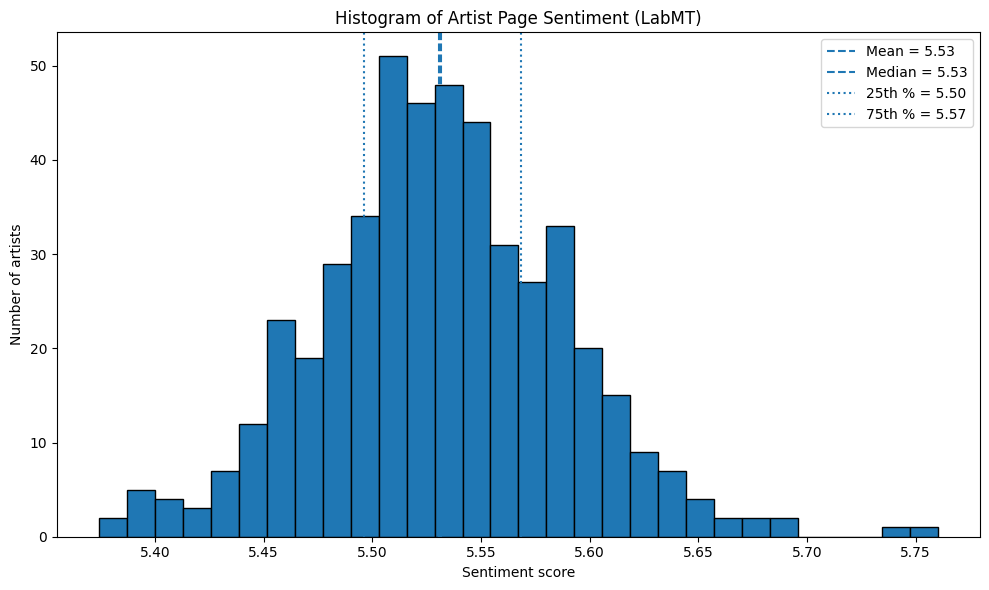

In [37]:
plt.figure(figsize=(10,6))
plt.hist(vals, bins=30, edgecolor="black")
plt.axvline(mean_s, linestyle="--", label=f"Mean = {mean_s:.2f}")
plt.axvline(median_s, linestyle="--", label=f"Median = {median_s:.2f}")
plt.axvline(q25, linestyle=":", label=f"25th % = {q25:.2f}")
plt.axvline(q75, linestyle=":", label=f"75th % = {q75:.2f}")
plt.title("Histogram of Artist Page Sentiment (LabMT)")
plt.xlabel("Sentiment score")
plt.ylabel("Number of artists")
plt.legend()
plt.tight_layout()


In [38]:
# Build sorted list of (artist, score)
pairs = [(n, s) for n, s in sentiment_map.items() if isinstance(s, (int, float)) and not np.isnan(s)]
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)

top10_happy = pairs_sorted[:10]
top10_sad = pairs_sorted[-10:]

print("Top 10 happiest pages:")
for n, s in top10_happy:
    print(f"  {n}: {s:.3f}")
print("\nTop 10 saddest pages:")
for n, s in top10_sad:
    print(f"  {n}: {s:.3f}")


Top 10 happiest pages:
  Lenny Kravitz: 5.760
  Tracy Chapman: 5.741
  Michael Martin Murphey: 5.695
  The Boxtones: 5.690
  Fun (band): 5.674
  The Cardigans: 5.670
  Train (band): 5.668
  Royal Blood (band): 5.667
  Counting Crows: 5.649
  Simple Plan: 5.649

Top 10 saddest pages:
  W.A.S.P. (band): 5.402
  Quiet Riot: 5.401
  Pantera: 5.400
  Canned Heat: 5.398
  Skid Row (American band): 5.398
  Sex Pistols: 5.396
  Five Finger Death Punch: 5.396
  Rage Against the Machine: 5.393
  Marilyn Manson: 5.385
  Gary Glitter: 5.374


### Calculate the sentiment of the band/artist pages (it is OK to work with the sub-network of artists-with-genre) and describe your findings using stats and visualization, inspired by the first exercise of week 8.

The sentiment distribution of artist Wikipedia pages is **high and tightly clustered**:

| Metric | Value |
|---|---|
| Mean | 5.532 |
| Median | 5.531 |
| 25% | 5.496 |
| 75% | 5.569 |
| Variance | 0.003 |

A LabMT score above ~5 indicates positive language, so most pages lean **consistently positive**, with very little spread. This fits Wikipedia’s tone - career achievements, awards, and legacy tend to dominate over conflict or tragedy.


### Summary

Wikipedia biographies for rock artists tend to use **neutral-to-positive language**, focusing on career highlights. A few controversial or politically charged acts pull sentiment down, but the overall emotional tone remains upbeat and consistent.


# Sentiment of artist pages (LabMT) — results and brief discussion


**Summary statistics**

| Metric   | Value |
| -------- | ----- |
| Mean     | 5.532 |
| Median   | 5.531 |
| 25%      | 5.496 |
| 75%      | 5.569 |
| Variance | 0.003 |

**Interpretation**

* Scores are centred around 5.53 with a small variance , indicating a tight, mildly positive distribution. Median and mean are almost identical, which suggests near symmetry.
* Relative to the LabMT neutral baseline near 5, artist pages lean slightly positive, consistent with descriptive and promotional language on Wikipedia‑style pages.
* The histogram looks bell‑shaped with modest tails. The happiest pages reach about 5.76; the saddest reach about 5.37. There are few extreme outliers.

**Top pages**

*Happiest (top 10)*: Lenny Kravitz (5.760), Tracy Chapman (5.741), Michael Martin Murphey (5.695), The Boxtones (5.690), Fun (band) (5.674), The Cardigans (5.670), Train (band) (5.668), Royal Blood (band) (5.667), Counting Crows (5.649), Simple Plan (5.649).

*Saddest (top 10)*: W.A.S.P. (band) (5.402), Quiet Riot (5.401), Pantera (5.400), Canned Heat (5.398), Skid Row (American band) (5.398), Sex Pistols (5.396), Five Finger Death Punch (5.396), Rage Against the Machine (5.393), Marilyn Manson (5.385), Gary Glitter (5.374).


Artist pages in the genre‑tagged sub‑network exhibit a narrow, near‑normal distribution of LabMT sentiment with a mean around 5.53 and small dispersion, implying broadly positive but not extreme language. The close agreement between mean and median and the narrow IQR indicate limited skew. The extremes are modest, suggesting that page tone varies by topic but remains mostly informative and neutral‑to‑positive overall. This matches expectations for encyclopedic descriptions that emphasise releases, awards, and reception rather than highly emotional language.

[0, 1, 2, 3, 4, 5]
   community  n_total  n_with_sent  coverage   mean  median    q25    q75  \
2          2       55           54     0.982  5.556   5.548  5.532  5.585   
1          1      147          147     1.000  5.546   5.545  5.514  5.585   
4          4       40           40     1.000  5.539   5.535  5.513  5.581   
3          3      150          149     0.993  5.528   5.517  5.494  5.555   
0          0       89           88     0.989  5.499   5.500  5.456  5.536   
5          5        3            3     1.000  5.486   5.489  5.471  5.502   

      sd  delta_vs_global                                               top3  \
2  0.051            0.024  [(Tracy Chapman, 5.741), (Counting Crows, 5.64...   
1  0.055            0.014  [(Fun (band), 5.674), (The Cardigans, 5.67), (...   
4  0.054            0.007  [(Kenny Loggins, 5.646), (Edgar Winter, 5.641)...   
3  0.052           -0.004  [(Lenny Kravitz, 5.76), (Michael Martin Murphe...   
0  0.058           -0.033  [(Living Colou

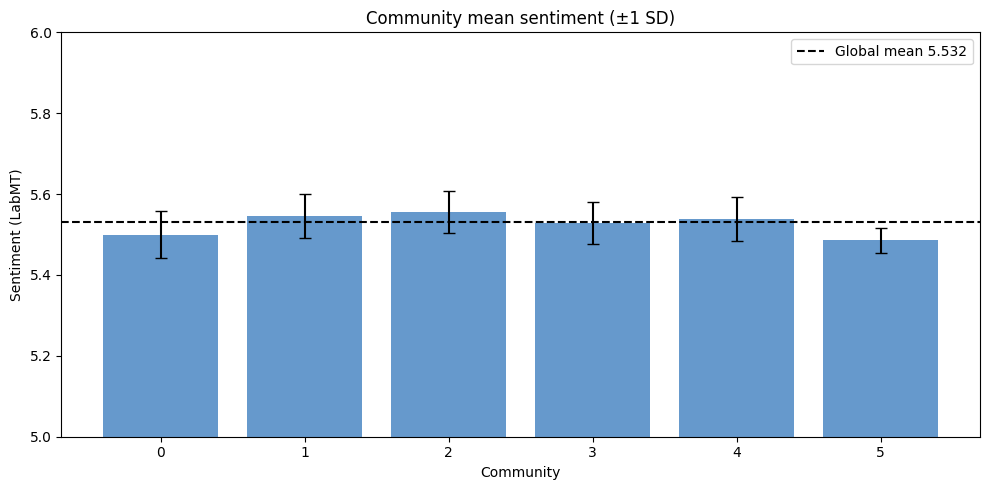


Interpretation:
 - Highest mean: community 2 at 5.556 (n=54/55 coverage=0.98).
 - Lowest mean: community 5 at 5.486 (n=3/3 coverage=1.00).
 - Spread: 0.070.
 - Top examples in best community: [('Tracy Chapman', 5.741), ('Counting Crows', 5.649), ('Matchbox Twenty', 5.648)]
 - Bottom examples in worst community: [('Parliament (band)', 5.453), ('Parliament-Funkadelic', 5.489), ('Funkadelic', 5.514)]


In [39]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

G = nx.read_graphml(OUTPUT_GRAPH)

def _as_comm(c):
    try:
        return int(c)
    except Exception:
        return c

def _to_float(x):
    if x is None:
        return None
    try:
        v = float(x)
        if np.isnan(v):
            return None
        return v
    except (TypeError, ValueError):
        return None

# Group sentiments by community and track total membership size
groups = defaultdict(list)      # comm -> list of (node, sentiment)
counts_by_comm = defaultdict(int)

for n, attrs in G.nodes(data=True):
    c = _as_comm(attrs.get("community"))
    if c is None:
        continue
    counts_by_comm[c] += 1
    s = _to_float(attrs.get("sentiment"))
    if s is not None:
        groups[c].append((n, s))

# Global sentiment over all nodes that have a sentiment
all_sents = [s for pairs in groups.values() for (_, s) in pairs]
if not all_sents:
    raise RuntimeError("Found no numeric 'sentiment' values. Ensure the graph contains the attribute or adjust attribute name.")

global_mean = float(np.mean(all_sents))
global_sd = float(np.std(all_sents, ddof=1)) if len(all_sents) > 1 else float("nan")

# Build per-community summary
summary_rows = []
print(sorted(counts_by_comm.keys(), key=lambda x: (isinstance(x, str), x)))
for c in sorted(counts_by_comm.keys(), key=lambda x: (isinstance(x, str), x)):
    sents = [s for (_, s) in groups.get(c, [])]
    n_total = counts_by_comm[c]
    n_with_sent = len(sents)
    if n_with_sent:
        mean = float(np.mean(sents))
        median = float(np.median(sents))
        q25 = float(np.percentile(sents, 25))
        q75 = float(np.percentile(sents, 75))
        sd = float(np.std(sents, ddof=1)) if n_with_sent > 1 else float("nan")
    else:
        mean = median = q25 = q75 = sd = float("nan")

    top3 = sorted(groups.get(c, []), key=lambda x: x[1], reverse=True)[:3]
    bottom3 = sorted(groups.get(c, []), key=lambda x: x[1])[:3]

    summary_rows.append({
        "community": c,
        "n_total": n_total,
        "n_with_sent": n_with_sent,
        "coverage": round(n_with_sent / n_total, 3) if n_total else 0.0,
        "mean": round(mean, 3) if not np.isnan(mean) else None,
        "median": round(median, 3) if not np.isnan(median) else None,
        "q25": round(q25, 3) if not np.isnan(q25) else None,
        "q75": round(q75, 3) if not np.isnan(q75) else None,
        "sd": round(sd, 3) if not np.isnan(sd) else None,
        "delta_vs_global": round((mean - global_mean), 3) if not np.isnan(mean) else None,
        "top3": [(n, round(s, 3)) for (n, s) in top3],
        "bottom3": [(n, round(s, 3)) for (n, s) in bottom3],
    })

import pandas as pd
summary_df = pd.DataFrame(summary_rows).sort_values("mean", ascending=False, na_position="last")
#display(summary_df)
print(summary_df)


print(f"\nGlobal sentiment mean = {global_mean:.3f} (sd={global_sd:.3f}) over {len(all_sents)} artists.")

# Bar plot: community means ±1 SD, with global mean line
valid_rows = [r for r in summary_rows if r["mean"] is not None]
comm_ids = [str(r["community"]) for r in valid_rows]
means = [r["mean"] for r in valid_rows]
errs = [r["sd"] if r["sd"] is not None else 0.0 for r in valid_rows]

plt.figure(figsize=(10, 5))
plt.bar(comm_ids, means, yerr=errs, capsize=4, color="#6699cc")
plt.axhline(global_mean, color="k", linestyle="--", label=f"Global mean {global_mean:.3f}")
plt.xlabel("Community")
plt.ylabel("Sentiment (LabMT)")
plt.title("Community mean sentiment (±1 SD)")
plt.ylim(5, 6)
plt.legend()
plt.tight_layout()
plt.show()

# Quick textual interpretation helpers
if valid_rows:
    best = max(valid_rows, key=lambda r: r["mean"])
    worst = min(valid_rows, key=lambda r: r["mean"])
    spread = best["mean"] - worst["mean"]
    print("\nInterpretation:")
    print(f" - Highest mean: community {best['community']} at {best['mean']:.3f} (n={best['n_with_sent']}/{best['n_total']} coverage={best['coverage']:.2f}).")
    print(f" - Lowest mean: community {worst['community']} at {worst['mean']:.3f} (n={worst['n_with_sent']}/{worst['n_total']} coverage={worst['coverage']:.2f}).")
    print(f" - Spread: {spread:.3f}.")
    print(f" - Top examples in best community: {best['top3']}")
    print(f" - Bottom examples in worst community: {worst['bottom3']}")

## Discuss the sentiment of the communities. Do the findings using TF-IDF during Lecture 7 help you understand your results?


The average sentiment in the network is 5.532 on the LabMT scale, showing a slightly positive tone overall. When sentiment is broken down by community, the group means remain very close to this global value. All communities fall within a narrow range around the global mean, and their error bars overlap. This indicates that there are no strong differences in page sentiment across structural groups.

Communities 1 through 4 sit just above or around the overall mean, while communities 0 and 5 are slightly below. The spread between the highest and lowest community averages is small and well under one standard deviation. This suggests that even though artists cluster structurally in the collaboration network, the language used on their pages remains consistently neutral to positive across clusters.

In summary, sentiment does not appear to be strongly structured by community. The encyclopedia style of the text likely dominates, leading to limited variation across groups despite different musical styles or network positions.
